# Planning Algorithms

Notebook này trình bày quy trình thực hành trực tiếp cho nhóm **Planning Algorithms** trên bài toán **Grid-world Navigation 8x8**. Mục tiêu không chỉ là chạy thuật toán, mà còn hiểu rõ cách mỗi thuật toán được xây dựng từ **Bellman equations**, cách khởi tạo model, cách gọi thuật toán, cách lấy metrics, đánh giá kết quả và trực quan hóa value function/policy thu được.

Trong Reinforcement Learning, **Planning Algorithms** được sử dụng khi agent biết trước mô hình đầy đủ của môi trường, tức là biết:

$$
P(s' \mid s,a)
$$

và

$$
r(s,a,s')
$$

Trong đó:

- $s$ là trạng thái hiện tại.
- $a$ là hành động agent chọn.
- $s'$ là trạng thái kế tiếp.
- $P(s' \mid s,a)$ là xác suất chuyển từ $s$ sang $s'$ khi thực hiện hành động $a$.
- $r(s,a,s')$ là reward nhận được khi chuyển từ $s$ sang $s'$.

Điểm khác biệt quan trọng giữa **Planning** và **Learning** là Planning không cần học bằng cách thử-sai qua nhiều episode trong môi trường. Thay vào đó, vì đã biết model của MDP, agent có thể tính toán trực tiếp expected return thông qua các Bellman equations.

MDP của bài toán được mô tả bởi:

$$
\mathcal{M} = (\mathcal{S}, \mathcal{A}, P, r, \gamma)
$$

Trong đó:

- $\mathcal{S}$: tập trạng thái.
- $\mathcal{A}$: tập hành động.
- $P$: transition model.
- $r$: reward function.
- $\gamma$: discount factor, dùng để cân bằng giữa reward hiện tại và reward tương lai.

Với Planning Algorithms, thao tác cốt lõi thường là tính kỳ vọng trên toàn bộ các trạng thái kế tiếp có thể xảy ra:

$$
\sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V(s')\right]
$$

Biểu thức này trả lời câu hỏi: nếu agent đang ở trạng thái $s$, chọn hành động $a$, rồi sau đó tiếp tục tối ưu hoặc đi theo một policy nào đó, thì expected return nhận được là bao nhiêu?

Trong project này, Planning environment cung cấp model thông qua API:

```python
env.get_transitions(state, action)
```

Hàm này cho biết các trạng thái kế tiếp có thể xảy ra, xác suất tương ứng, reward và trạng thái kết thúc nếu có. Đây là điểm quan trọng giúp Planning Algorithms có thể tính toán Bellman backup trực tiếp.

Notebook này tập trung vào bốn thuật toán Planning chính:

1. **Policy Evaluation**: đánh giá một policy cố định $\pi$ bằng cách tính state-value function $V^\pi(s)$.
2. **Policy Iteration**: tìm policy tối ưu bằng cách lặp giữa hai bước: đánh giá policy hiện tại và cải thiện policy theo hướng greedy.
3. **Value Iteration**: tìm trực tiếp optimal value function $V^*(s)$ bằng Bellman optimality backup, sau đó trích xuất optimal policy.
4. **Linear Programming Planner**: biểu diễn bài toán tìm $V^*$ dưới dạng một bài toán tối ưu tuyến tính dựa trên Bellman optimality inequalities.

Về mặt thực nghiệm, notebook sẽ đi theo luồng:

1. Tạo môi trường Grid-world 8x8.
2. Khởi tạo từng thuật toán Planning.
3. Gọi `.run()` để chạy thuật toán.
4. Lấy value function, policy và metrics.
5. Đánh giá kết quả bằng các metrics như residual, value error, policy agreement và runtime.
6. Trực quan hóa value heatmap, policy arrows và convergence curves nếu có helper tương ứng.

Vai trò của nhóm Planning trong toàn bộ project là rất quan trọng vì nó cung cấp các nghiệm/baseline có độ tin cậy cao. Cụ thể:

- **Policy Evaluation** đóng vai trò baseline cho các thuật toán prediction như TD(0) và TD($\lambda$).
- **Value Iteration** đóng vai trò baseline cho các thuật toán control như SARSA và Q-learning.
- **Policy Iteration** và **Linear Programming Planner** được so sánh với Value Iteration để kiểm tra tính nhất quán của nghiệm tối ưu.

Do đó, phần Planning không chỉ giúp hiểu các thuật toán model-based, mà còn là nền tảng để đánh giá các thuật toán Learning ở notebook tiếp theo.


## Thiết lập môi trường

### Thiết lập project root

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/home/phat/AI_Project/Reinforcement-Learning')

### Import thư viện, model, metrics và visualization

In [2]:
from pathlib import Path
from time import perf_counter

from envs.planning_grid_world import PlanningGridWorld
from agents.planning import (
    PolicyEvaluation,
    PolicyIteration,
    ValueIteration,
    LinearProgrammingPlanner,
)
from utils.metrics import mean_squared_error, max_abs_error, policy_agreement
from utils.visualization import (
    plot_grid_world_layout,
    plot_value_heatmap,
    plot_policy_arrows,
    plot_policy_changes,
    plot_bellman_residual,
    plot_comparison_bar,
)

NOTEBOOK_FIGURE_DIR = PROJECT_ROOT / "report" / "figures" / "planning"
NOTEBOOK_VERBOSE = 2
NOTEBOOK_LOG_INTERVAL = 100

NOTEBOOK_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURE_DIR

PosixPath('/home/phat/AI_Project/Reinforcement-Learning/report/figures/planning')

### Helper functions cho notebook

In [3]:
def show_metrics(metrics, keys=None):
    if metrics is None:
        print("No metrics available.")
        return
    selected = metrics if keys is None else {key: metrics.get(key) for key in keys}
    for key, value in selected.items():
        print(f"{key}: {value}")

## Thiết kế Grid-world 8x8

Trong project này, môi trường được sử dụng là **Grid-world Navigation 8x8**, một môi trường rời rạc đơn giản nhưng rất phù hợp để minh họa các khái niệm cốt lõi trong Reinforcement Learning, đặc biệt là **Markov Decision Process (MDP)** và các **Planning Algorithms**.

Mỗi trạng thái trong môi trường được biểu diễn bởi một ô có tọa độ:

$$
s = (row, col)
$$

Agent có thể thực hiện một trong bốn hành động cơ bản:

$$
\mathcal{A} = \{up, down, left, right\}
$$

Trong bố cục Grid-world:

- **Start state** là vị trí khởi đầu của agent.
- **Goal states** là các trạng thái đích; khi agent đi tới đây, episode kết thúc với phần thưởng dương.
- **Trap states** là các trạng thái bất lợi; khi agent rơi vào đây, episode kết thúc với phần thưởng âm.
- **Wall states** là các ô chướng ngại; agent không thể đi xuyên qua.
- **Step reward** được áp dụng cho mỗi bước di chuyển, nhằm khuyến khích agent tìm đường đi hiệu quả.

Về mặt hình thức, Grid-world được mô hình hóa như một MDP:

$$
\mathcal{M} = (\mathcal{S}, \mathcal{A}, P, r, \gamma)
$$

trong đó:

- $\mathcal{S}$ là tập trạng thái.
- $\mathcal{A}$ là tập hành động.
- $P(s' \mid s,a)$ là xác suất chuyển trạng thái.
- $r(s,a,s')$ là hàm phần thưởng.
- $\gamma$ là hệ số chiết khấu.

Điểm quan trọng của môi trường `PlanningGridWorld` là agent có thể truy cập trực tiếp mô hình chuyển trạng thái thông qua API:

```python
env.get_transitions(state, action)
```

Điều này cho phép các thuật toán Planning tính toán Bellman backup trực tiếp từ model, thay vì phải học thông qua tương tác mẫu như các thuật toán Learning.

Trong notebook này, môi trường sẽ được khởi tạo với cấu hình mặc định của project, nhằm đảm bảo toàn bộ các thuật toán Planning được đánh giá trên cùng một bài toán chuẩn.


In [4]:
planning_env = PlanningGridWorld()
planning_env

In [5]:
print("Grid size:", planning_env.grid_size)
print("Start state:", planning_env.start_state)
print("Goal states:", planning_env.goal_states)
print("Trap states:", planning_env.trap_states)
print("Wall states:", planning_env.wall_states)
print("Actions:", planning_env.actions)
print("Reward config:", planning_env.reward_config)
print("Gamma:", planning_env.gamma)
print("Number of states:", planning_env.num_states())

Grid size: (8, 8)
Start state: (0, 0)
Goal states: {(7, 7)}
Trap states: {(4, 4), (3, 3)}
Wall states: {(2, 3), (5, 5), (2, 2)}
Actions: ('up', 'down', 'left', 'right')
Reward config: {'step': -1.0, 'goal': 10.0, 'trap': -10.0, 'wall': -1.0}
Gamma: 0.99
Number of states: 61


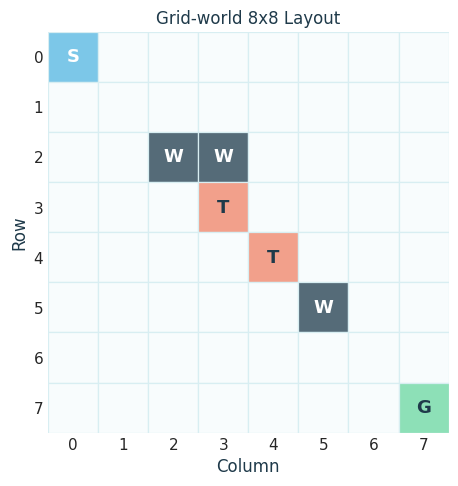

(<Figure size 640x520 with 1 Axes>,
 <Axes: title={'center': 'Grid-world 8x8 Layout'}, xlabel='Column', ylabel='Row'>)

In [6]:
layout_path = NOTEBOOK_FIGURE_DIR / "grid_world_layout.png"
plot_grid_world_layout(
    planning_env,
    title="Grid-world 8x8 Layout",
    save_path=layout_path,
    show=True,
)

**Nhận xét về bố cục Grid-world**

Hình trên cho thấy trực quan cấu trúc của môi trường Grid-world 8x8 được sử dụng trong project. Agent bắt đầu từ ô **Start (S)** và cần tìm đường đi tới ô **Goal (G)**, đồng thời tránh các ô **Trap (T)** và không thể đi xuyên qua các ô **Wall (W)**.

Việc trực quan hóa bố cục môi trường có ý nghĩa quan trọng vì nó giúp giải thích trực giác của value function và policy ở các phần sau. Cụ thể:

- Các trạng thái gần Goal thường có giá trị cao hơn.
- Các trạng thái gần Trap thường có giá trị thấp hơn.
- Các Wall làm thay đổi cấu trúc đường đi tối ưu.
- Policy tối ưu về sau sẽ phản ánh cách agent di chuyển quanh các chướng ngại để đến Goal hiệu quả nhất.

Do đó, phần trực quan hóa Grid-world là bước khởi đầu cần thiết trước khi đi vào từng thuật toán Planning cụ thể.

## Xây dựng và chạy các thuật toán Planning

Trong phần này, ta sẽ lần lượt xây dựng và chạy bốn thuật toán thuộc nhóm **Planning Algorithms** trên cùng một môi trường Grid-world 8x8:

1. **Policy Evaluation**
2. **Policy Iteration**
3. **Value Iteration**
4. **Linear Programming Planner**

### Policy Evaluation

**Policy Evaluation** là bài toán đánh giá chất lượng của một policy cố định $\pi$. Nói cách khác, ta giả sử agent đã có sẵn một chiến lược hành động, sau đó cần tính xem nếu agent luôn hành động theo policy đó thì mỗi state có giá trị kỳ vọng là bao nhiêu.

Giá trị cần tính là **state-value function**:

$$
V^\pi(s) = \mathbb{E}_\pi\left[G_t \mid S_t = s\right]
$$

Trong đó:

- $V^\pi(s)$ là expected return khi bắt đầu từ state $s$ và đi theo policy $\pi$.
- $G_t$ là return từ thời điểm $t$.
- Kỳ vọng $\mathbb{E}_\pi$ được lấy theo policy $\pi$ và dynamics của môi trường.

Vì Planning environment biết đầy đủ model $P(s' \mid s,a)$ và $r(s,a,s')$, ta có thể tính $V^\pi$ bằng **Bellman Expectation Equation**:

$$
V^\pi(s) = \sum_a \pi(a \mid s) \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V^\pi(s')\right]
$$

Công thức trên nói rằng giá trị của state $s$ bằng kỳ vọng trên tất cả action mà policy có thể chọn, và trên tất cả next state mà môi trường có thể chuyển tới.

Trong project này, nếu không truyền policy vào `PolicyEvaluation`, class sẽ dùng **uniform random policy** mặc định. Điều này có nghĩa là tại mỗi state không kết thúc, agent chọn các action hợp lệ với xác suất bằng nhau.

Policy Evaluation **không tìm policy tối ưu**. Nó chỉ trả lời câu hỏi: nếu agent đi theo policy $\pi$ đã cho, thì mỗi state tốt hay xấu đến mức nào?

Quy trình thực hiện trong notebook:

1. Khởi tạo `PolicyEvaluation`.
2. Gọi `.run()` để thực hiện iterative Bellman expectation backup.
3. Lấy value function $V^\pi$.
4. Lấy metrics hội tụ như residual, số iterations và số Bellman backups.
5. Trực quan hóa $V^\pi$ bằng heatmap.
6. Trực quan hóa Bellman residual để quan sát quá trình hội tụ.


In [7]:
policy_evaluator = PolicyEvaluation(
    env=planning_env,
    policy=None,
    theta=1e-6,
    max_iterations=1000,
    verbose=NOTEBOOK_VERBOSE,
    log_interval=NOTEBOOK_LOG_INTERVAL,
)

start_time = perf_counter()
pe_result = policy_evaluator.run()
pe_runtime = perf_counter() - start_time

pe_values = policy_evaluator.get_value_function()
pe_policy = policy_evaluator.get_policy()
pe_metrics = policy_evaluator.get_metrics()
pe_metrics["notebook_runtime_sec"] = pe_runtime

[PolicyEvaluation] Convergence progress
  iter   | residual   | backups
  ------ | ---------- | -------
     100 |  1.325e-01 |    5800


     200 |  1.066e-02 |   11600
     300 |  8.496e-04 |   17400
     400 |  6.772e-05 |   23200
     500 |  5.398e-06 |   29000
     567 |  9.915e-07 |   32886


In [8]:
sample_state = planning_env.start_state

print("Sample state:", sample_state)
print("Policy at sample state:")

for action, prob in pe_policy[sample_state].items():
    print(f"  {action}: {prob:.3f}")

print("Sum of action probabilities:", sum(pe_policy[sample_state].values()))

Sample state: (0, 0)
Policy at sample state:
  up: 0.250
  down: 0.250
  left: 0.250
  right: 0.250
Sum of action probabilities: 1.0


In [9]:
show_metrics(pe_metrics, keys=[
    "status",
    "iterations",
    "final_bellman_residual",
    "bellman_backups",
    "notebook_runtime_sec",
])

print("Residual < theta:", pe_metrics["final_bellman_residual"] < pe_metrics["theta"])

status: converged
iterations: 567
final_bellman_residual: 9.914539589317428e-07
bellman_backups: 32886
notebook_runtime_sec: 0.3935878739994223
Residual < theta: True


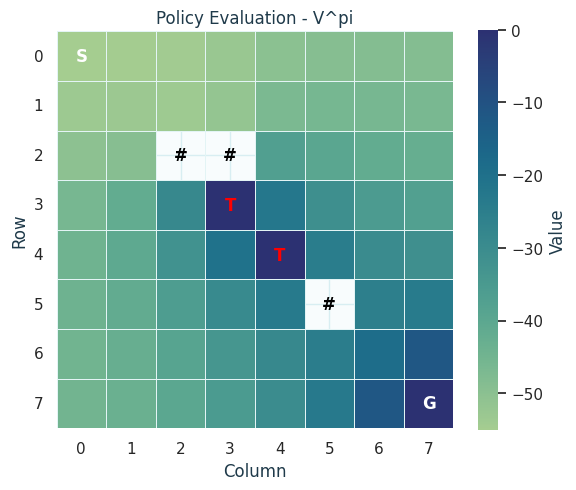

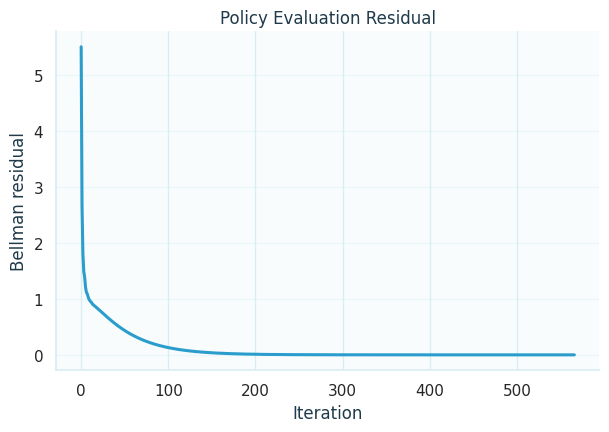

In [10]:
pe_value_path = NOTEBOOK_FIGURE_DIR / "policy_evaluation_value_heatmap.png"
pe_residual_path = NOTEBOOK_FIGURE_DIR / "policy_evaluation_residual.png"

plot_value_heatmap(
    pe_values,
    planning_env,
    "Policy Evaluation - V^pi",
    save_path=pe_value_path,
    show=True,
)

plot_bellman_residual(
    pe_metrics["bellman_residuals"],
    "Policy Evaluation Residual",
    save_path=pe_residual_path,
    show=True,
);

**Nhận xét kết quả Policy Evaluation:**

Kết quả cho thấy `PolicyEvaluation` đã hội tụ thành công. Thuật toán dừng tại iteration 567 với:

$$
\text{final\_bellman\_residual} = 9.915 \times 10^{-7} < \theta = 10^{-6}
$$

Điều này cho thấy value function thu được đã gần đạt fixed point của Bellman Expectation Equation:

$$
V^\pi = T^\pi V^\pi
$$

Policy đang được đánh giá là **uniform random policy**. Tại start state $(0, 0)$, bốn hành động `up`, `down`, `left`, `right` đều có xác suất 0.25, tức là:

$$
\pi(a \mid s) = 0.25
$$

Vì vậy, $V^\pi$ trong heatmap phản ánh chất lượng của một agent hành động ngẫu nhiên, không phải agent tối ưu.

Trong heatmap, phần lớn state có value âm. Điều này hợp lý vì agent ngẫu nhiên có thể đi lòng vòng, chịu step cost qua nhiều bước và có khả năng rơi vào Trap. Các state dễ dẫn tới Goal hơn có value cao hơn, trong khi các state gần Trap hoặc khó tiếp cận Goal có value thấp hơn.

Biểu đồ Bellman residual giảm dần về gần 0, cho thấy quá trình Bellman expectation backup hội tụ ổn định. Kết quả này sẽ được dùng như baseline cho các thuật toán prediction như TD(0) và TD($\lambda$) ở phần Learning Algorithms.


### Policy Iteration

**Policy Iteration** là thuật toán tìm policy tối ưu bằng cách lặp lại hai bước: **Policy Evaluation** và **Policy Improvement**. Nếu Policy Evaluation chỉ đánh giá một policy cố định $\pi$, thì Policy Iteration sử dụng kết quả đánh giá đó để cải thiện policy, từ đó tiến dần đến policy tối ưu $\pi^*$.

Mục tiêu của thuật toán là tìm:

$$
\pi^*(s)
$$

và value function tương ứng:

$$
V^*(s)
$$

Trong đó:

- $\pi^*(s)$ là hành động tối ưu tại state $s$.
- $V^*(s)$ là expected return tối đa có thể đạt được khi bắt đầu từ state $s$.
- Policy tối ưu là policy không thể được cải thiện thêm bằng bước greedy improvement.

Policy Iteration gồm hai bước chính.

**Bước 1: Policy Evaluation**

Với policy hiện tại $\pi_k$, thuật toán tính value function $V^{\pi_k}(s)$ bằng Bellman Expectation Equation:

$$
V^{\pi_k}(s) = \sum_a \pi_k(a \mid s) \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V^{\pi_k}(s')\right]
$$

Bước này trả lời câu hỏi: nếu agent đi theo policy hiện tại $\pi_k$, thì mỗi state có giá trị kỳ vọng là bao nhiêu?

**Bước 2: Policy Improvement**

Sau khi có $V^{\pi_k}$, thuật toán cải thiện policy bằng cách chọn action có expected return lớn nhất tại mỗi state:

$$
\pi_{k+1}(s) = \arg\max_a \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V^{\pi_k}(s')\right]
$$

Công thức trên nói rằng tại mỗi state $s$, ta thử xét tất cả action $a$, tính expected return nếu chọn action đó rồi tiếp tục dựa trên value function hiện tại, sau đó chọn action tốt nhất.

Thuật toán dừng khi policy không còn thay đổi:

$$
\pi_{k+1}(s) = \pi_k(s), \quad \forall s \in \mathcal{S}
$$

Khi điều kiện này xảy ra, policy được xem là **stable**. Trong MDP hữu hạn, nếu quá trình policy evaluation và improvement được thực hiện đúng, policy stable chính là policy tối ưu.

Trong project này, `PolicyIteration` sử dụng `PlanningGridWorld`, do đó thuật toán có thể truy cập model đầy đủ thông qua `get_transitions(state, action)`. Điều này cho phép thuật toán tính chính xác expected return trong cả bước evaluation và improvement.

Policy Iteration khác với Policy Evaluation ở điểm quan trọng: **Policy Evaluation chỉ đánh giá policy**, còn **Policy Iteration vừa đánh giá vừa cải thiện policy**.

Quy trình thực hiện trong notebook:

1. Khởi tạo `PolicyIteration`.
2. Gọi `.run()` để thực hiện vòng lặp evaluation-improvement.
3. Lấy value function sau khi policy ổn định.
4. Lấy greedy policy cuối cùng.
5. Lấy metrics như số vòng policy improvement, tổng số vòng policy evaluation, Bellman backups và runtime.
6. Trực quan hóa value function bằng heatmap.
7. Trực quan hóa policy cuối cùng bằng policy arrows.
8. Quan sát số state thay đổi action qua từng vòng improvement nếu có metrics tương ứng.

Một điểm cần chú ý là `policy_changes_per_iteration` **không phải Bellman residual**. Nó đo số lượng state bị thay đổi action sau mỗi vòng policy improvement. Khi giá trị này giảm về 0, policy đã ổn định.


In [11]:
policy_iteration = PolicyIteration(
    env=planning_env,
    theta=1e-6,
    max_iterations=1000,
    verbose=NOTEBOOK_VERBOSE,
    log_interval=NOTEBOOK_LOG_INTERVAL,
)

start_time = perf_counter()
pi_result = policy_iteration.run()
pi_runtime = perf_counter() - start_time

pi_values = policy_iteration.get_value_function()
pi_policy = policy_iteration.get_policy()
pi_metrics = policy_iteration.get_metrics()
pi_metrics["notebook_runtime_sec"] = pi_runtime

[PolicyIteration] Convergence progress
  iter   | residual   | backups
  ------ | ---------- | -------
      12 |  0.000e+00 |   81490


In [12]:
show_metrics(pi_metrics, keys=[
    "status",
    "theta",
    "policy_stable",
    "policy_improvement_iterations",
    "total_policy_evaluation_iterations",
    "final_bellman_residual",
    "bellman_backups",
    "notebook_runtime_sec",
])

policy_changes = pi_metrics.get("policy_changes_per_iteration", [])
if policy_changes:
    print("Final policy changes:", policy_changes[-1])

status: converged
theta: 1e-06
policy_stable: True
policy_improvement_iterations: 12
total_policy_evaluation_iterations: 1405
final_bellman_residual: 0.0
bellman_backups: 81490
notebook_runtime_sec: 0.2813913939990016
Final policy changes: 0


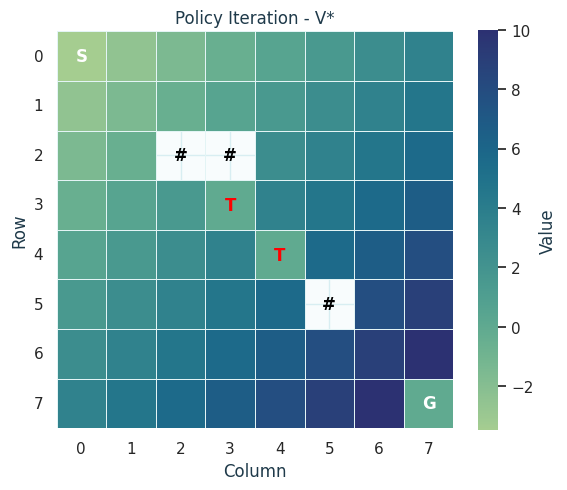

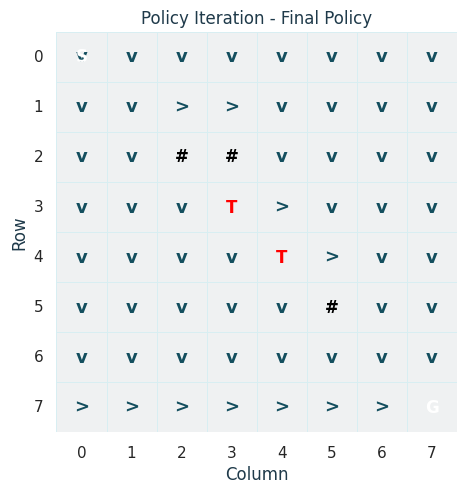

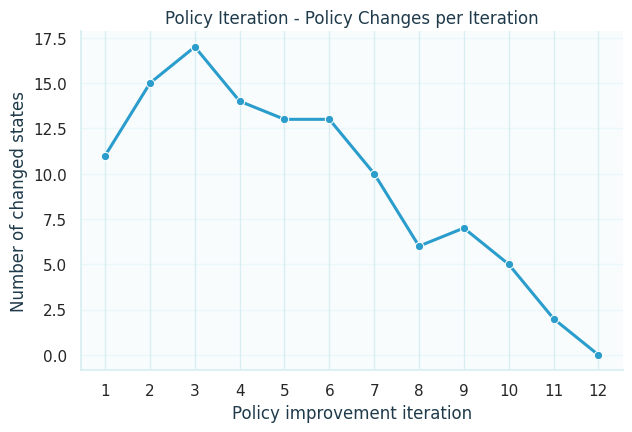

In [13]:
pi_value_path = NOTEBOOK_FIGURE_DIR / "policy_iteration_value_heatmap.png"
pi_policy_path = NOTEBOOK_FIGURE_DIR / "policy_iteration_policy.png"
pi_changes_path = NOTEBOOK_FIGURE_DIR / "policy_iteration_policy_changes.png"

plot_value_heatmap(
    pi_values,
    planning_env,
    "Policy Iteration - V*",
    save_path=pi_value_path,
    show=True,
)

plot_policy_arrows(
    pi_policy,
    planning_env,
    "Policy Iteration - Final Policy",
    save_path=pi_policy_path,
    show=True,
)

plot_policy_changes(
    pi_metrics["policy_changes_per_iteration"],
    title="Policy Iteration - Policy Changes per Iteration",
    save_path=pi_changes_path,
    show=True,
);

**Nhận xét kết quả Policy Iteration:**

Kết quả cho thấy `PolicyIteration` đã hội tụ thành công. Thuật toán dừng sau 12 vòng policy improvement, với trạng thái:

```python
policy_stable = True
```

và số state thay đổi action ở vòng cuối bằng:

$$
\Delta_{\pi, final} = 0
$$

Điều này nghĩa là policy không còn thay đổi sau bước improvement cuối cùng:

$$
\pi_{k+1}(s) = \pi_k(s), \quad \forall s \in \mathcal{S}
$$

Do đó, policy cuối cùng có thể xem là policy ổn định mà thuật toán tìm được.

So với Policy Evaluation, điểm khác biệt quan trọng là Policy Iteration không chỉ đánh giá một policy cố định. Thuật toán lặp lại hai bước:

1. Đánh giá policy hiện tại bằng Bellman Expectation Equation.
2. Cải thiện policy bằng cách chọn action tốt nhất tại mỗi state.

Quá trình này được thể hiện rõ qua biểu đồ **Policy Changes per Iteration**. Ban đầu số state thay đổi action còn lớn, nghĩa là policy vẫn đang được cải thiện mạnh. Về các iteration cuối, số state thay đổi giảm dần và cuối cùng bằng 0, cho thấy policy đã ổn định.

Value heatmap cho thấy các state gần Goal hoặc dễ dẫn tới Goal có giá trị cao hơn. Ngược lại, các state gần Trap hoặc bị ảnh hưởng bởi Wall có giá trị thấp hơn. Điều này phù hợp với trực giác của bài toán Grid-world: agent nên tìm đường tới Goal, tránh Trap và đi vòng qua Wall.

Biểu đồ **Final Policy** cho thấy hướng di chuyển mà agent chọn sau khi policy đã hội tụ. Các mũi tên nhìn chung hướng agent về vùng Goal, đồng thời tránh các ô Trap và Wall. Đây là kết quả hợp lý vì Policy Iteration đã sử dụng model đầy đủ của môi trường để tính expected return và cải thiện policy.

Tóm lại, Policy Iteration đã tìm được một policy ổn định thông qua quá trình evaluation-improvement. Kết quả này sẽ được dùng để so sánh với Value Iteration ở phần tiếp theo, vì cả hai thuật toán đều hướng tới nghiệm tối ưu của bài toán Planning.


### Value Iteration

**Value Iteration** là thuật toán Planning dùng để tìm trực tiếp optimal value function $V^*(s)$ thông qua **Bellman Optimality Backup**. Khác với Policy Iteration, thuật toán này không tách rõ hai bước policy evaluation và policy improvement, mà cập nhật value function theo hướng tối ưu ngay trong mỗi iteration.

Mục tiêu của thuật toán là tìm:

$$
V^*(s)
$$

và sau đó trích xuất policy tối ưu:

$$
\pi^*(s)
$$

Trong đó:

- $V^*(s)$ là expected return lớn nhất có thể đạt được khi bắt đầu từ state $s$.
- $\pi^*(s)$ là action tối ưu tại state $s$.
- Policy tối ưu được lấy bằng cách chọn action có expected return cao nhất theo $V^*$.

Bellman Optimality Equation được viết như sau:

$$
V^*(s) = \max_a \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V^*(s')\right]
$$

Trong thực tế, Value Iteration tìm nghiệm bằng cách lặp cập nhật:

$$
V_{k+1}(s) = \max_a \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V_k(s')\right]
$$

Công thức trên nói rằng tại mỗi state $s$, thuật toán thử tất cả action $a$, tính expected return nếu chọn action đó, rồi lấy action tốt nhất. Đây chính là điểm khác biệt quan trọng so với Policy Evaluation, vì Policy Evaluation lấy kỳ vọng theo policy cố định, còn Value Iteration lấy giá trị lớn nhất trên toàn bộ action.

Sau khi value function hội tụ, policy tối ưu được trích xuất bằng:

$$
\pi^*(s) = \arg\max_a \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V^*(s')\right]
$$

Trong project này, `ValueIteration` sử dụng `PlanningGridWorld`, nên thuật toán có thể truy cập model đầy đủ thông qua `get_transitions(state, action)`. Vì vậy, mỗi Bellman optimality backup được tính trực tiếp từ transition model của môi trường.

Value Iteration có vai trò rất quan trọng trong project vì nó được dùng làm baseline tối ưu cho các thuật toán control như SARSA và Q-learning. Ngoài ra, kết quả của Value Iteration cũng được dùng để so sánh với Policy Iteration và Linear Programming Planner.

Quy trình thực hiện trong notebook:

1. Khởi tạo `ValueIteration`.
2. Gọi `.run()` để thực hiện Bellman optimality backup.
3. Lấy optimal value function $V^*$.
4. Lấy optimal policy $\pi^*$.
5. Lấy metrics như số iterations, Bellman residual, Bellman backups và runtime.
6. Trực quan hóa $V^*$ bằng heatmap.
7. Trực quan hóa policy tối ưu bằng policy arrows.
8. Trực quan hóa Bellman residual để quan sát quá trình hội tụ.


In [14]:
value_iteration = ValueIteration(
    env=planning_env,
    theta=1e-6,
    max_iterations=1000,
    verbose=NOTEBOOK_VERBOSE,
    log_interval=NOTEBOOK_LOG_INTERVAL,
)

start_time = perf_counter()
vi_result = value_iteration.run()
vi_runtime = perf_counter() - start_time

vi_values = value_iteration.get_value_function()
vi_policy = value_iteration.get_policy()
vi_metrics = value_iteration.get_metrics()
vi_metrics["notebook_runtime_sec"] = vi_runtime

[ValueIteration] Convergence progress
  iter   | residual   | backups
  ------ | ---------- | -------
      15 |  0.000e+00 |     870


In [15]:
show_metrics(vi_metrics, keys=[
    "status",
    "theta",
    "iterations",
    "final_bellman_residual",
    "bellman_backups",
    "notebook_runtime_sec",
])

print("Residual < theta:", vi_metrics["final_bellman_residual"] < vi_metrics["theta"])

status: converged
theta: 1e-06
iterations: 15
final_bellman_residual: 0.0
bellman_backups: 870
notebook_runtime_sec: 0.014273331000367762
Residual < theta: True


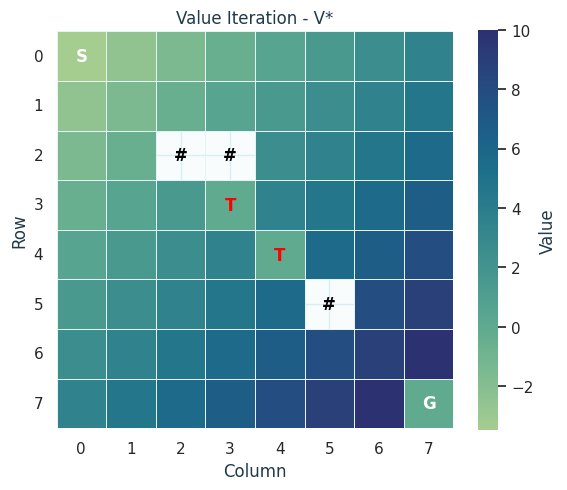

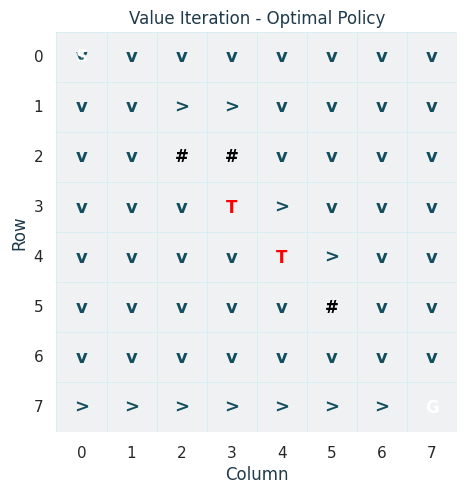

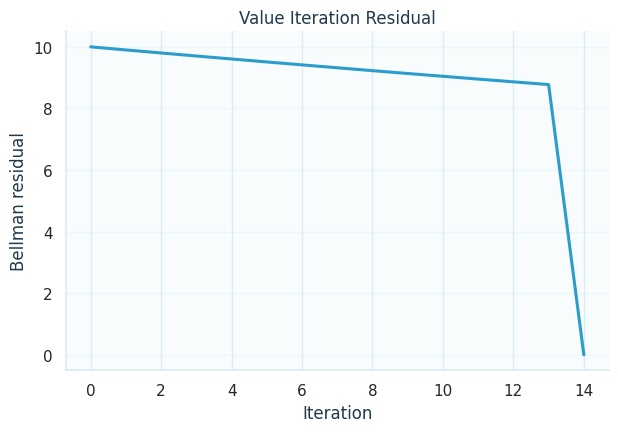

In [16]:
vi_value_path = NOTEBOOK_FIGURE_DIR / "value_iteration_value_heatmap.png"
vi_policy_path = NOTEBOOK_FIGURE_DIR / "value_iteration_policy.png"
vi_residual_path = NOTEBOOK_FIGURE_DIR / "value_iteration_residual.png"

plot_value_heatmap(
    vi_values,
    planning_env,
    "Value Iteration - V*",
    save_path=vi_value_path,
    show=True,
)

plot_policy_arrows(
    vi_policy,
    planning_env,
    "Value Iteration - Optimal Policy",
    save_path=vi_policy_path,
    show=True,
)

plot_bellman_residual(
    vi_metrics["bellman_residuals"],
    "Value Iteration Residual",
    save_path=vi_residual_path,
    show=True,
);

**Nhận xét kết quả Value Iteration:**

Kết quả cho thấy `ValueIteration` đã hội tụ rất nhanh. Thuật toán dừng sau 15 iterations với Bellman residual cuối cùng bằng 0.0, thỏa điều kiện:

$$
\Delta_{final} = 0 < \theta = 10^{-6}
$$

Điều này cho thấy value function thu được đã đạt fixed point của Bellman Optimality Operator:

$$
V^* = T^* V^*
$$

Khác với Policy Evaluation, Value Iteration không đánh giá một policy cố định. Tại mỗi state, thuật toán trực tiếp chọn action có expected return lớn nhất thông qua phép tối ưu:

$$
V_{k+1}(s) = \max_a \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V_k(s')\right]
$$

Do đó, value function thu được là optimal value function $V^*$.

Value heatmap cho thấy các state gần Goal hoặc dễ dẫn tới Goal có giá trị cao hơn, trong khi các state gần Trap hoặc bị ảnh hưởng bởi Wall có giá trị thấp hơn. Điều này phù hợp với trực giác của Grid-world: agent cần tìm đường đi tới Goal, tránh Trap và đi vòng qua Wall.

Biểu đồ **Optimal Policy** cho thấy policy tối ưu được trích xuất từ $V^*$. Các mũi tên biểu diễn hành động greedy tại từng state, tức là hành động có expected return cao nhất theo value function đã hội tụ.

Biểu đồ Bellman residual cho thấy residual giảm về 0 sau số iteration rất nhỏ. Điều này phản ánh việc reward từ Goal/Trap được lan truyền ngược qua state space thông qua Bellman optimality backup, cho đến khi không còn cập nhật đáng kể nào nữa.

Tóm lại, Value Iteration trực tiếp tìm nghiệm tối ưu của bài toán Planning. Kết quả $V^*$ và policy tối ưu từ thuật toán này sẽ được dùng làm baseline quan trọng để so sánh với Policy Iteration, Linear Programming Planner, đồng thời làm baseline cho các thuật toán control như SARSA và Q-learning ở notebook Learning.


### Linear Programming Planner

**Linear Programming Planner** là cách tiếp cận giải bài toán MDP bằng tối ưu tuyến tính. Thay vì lặp Bellman backup như Policy Iteration hoặc Value Iteration, phương pháp này biểu diễn điều kiện tối ưu của MDP thành một hệ bất đẳng thức tuyến tính, sau đó dùng solver để tìm value function tối ưu.

Mục tiêu của thuật toán là tìm optimal value function:

$$
V^*(s)
$$

Sau đó, policy tối ưu được trích xuất bằng cách chọn action tốt nhất theo nghiệm $V^*$:

$$
\pi^*(s) = \arg\max_a \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V^*(s')\right]
$$

Ý tưởng cốt lõi của Linear Programming formulation đến từ Bellman Optimality Equation:

$$
V^*(s) = \max_a \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V^*(s')\right]
$$

Điều kiện trên có thể được viết lại thành các Bellman optimality inequalities:

$$
V(s) \ge \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V(s')\right], \quad \forall s \in \mathcal{S}, \forall a \in \mathcal{A}
$$

Tức là, với mỗi state-action pair $(s,a)$, giá trị $V(s)$ phải không nhỏ hơn expected return khi chọn action $a$ tại state $s$.

Bài toán tối ưu tuyến tính thường được viết dưới dạng:

$$
\min_V \sum_{s \in \mathcal{S}} V(s)
$$

subject to:

$$
V(s) \ge \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V(s')\right], \quad \forall s,a
$$

Trực giác của objective $\min_V \sum_s V(s)$ là tìm value function nhỏ nhất thỏa tất cả Bellman optimality inequalities. Nghiệm nhỏ nhất này chính là optimal value function $V^*$.

Trong project này, `LinearProgrammingPlanner` sử dụng `PlanningGridWorld`, nên nó có thể lấy toàn bộ transition model thông qua `get_transitions(state, action)` để xây dựng biến, constraints và giải bài toán LP.

Quy trình thực hiện trong notebook:

1. Khởi tạo `LinearProgrammingPlanner`.
2. Gọi `.run()` để xây dựng và giải bài toán tối ưu tuyến tính.
3. Lấy value function từ nghiệm LP.
4. Trích xuất derived policy từ nghiệm value function.
5. Lấy solver metrics như số biến, số ràng buộc, solver iterations và runtime.
6. Trực quan hóa value function bằng heatmap.
7. Trực quan hóa derived policy bằng policy arrows.
8. Ở phần so sánh sau, đối chiếu nghiệm LP với Value Iteration.


In [17]:
lp_planner = LinearProgrammingPlanner(
    env=planning_env,
    verbose=NOTEBOOK_VERBOSE,
)

start_time = perf_counter()
lp_result = lp_planner.run()
lp_runtime = perf_counter() - start_time

lp_values = lp_planner.get_value_function()
lp_policy = lp_planner.get_policy()
lp_metrics = lp_planner.get_metrics()
lp_metrics["notebook_runtime_sec"] = lp_runtime

[LinearProgrammingPlanner] variables=61 constraints=232


In [18]:
show_metrics(lp_metrics, keys=[
    "status",
    "number_of_variables",
    "number_of_constraints",
    "solver_iterations",
    "notebook_runtime_sec",
])

status: optimal
number_of_variables: 61
number_of_constraints: 232
solver_iterations: 71
notebook_runtime_sec: 0.03152001600028598


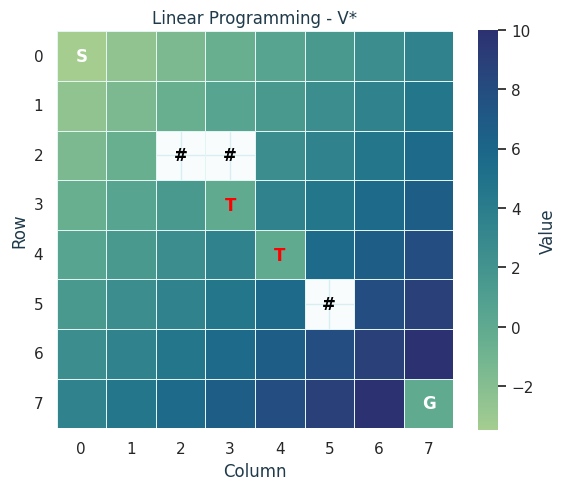

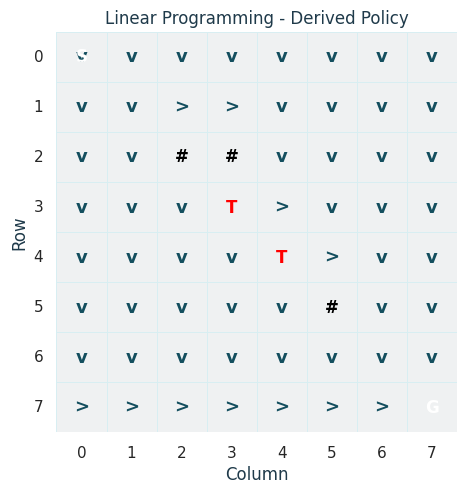

In [19]:
lp_value_path = NOTEBOOK_FIGURE_DIR / "linear_programming_value_heatmap.png"
lp_policy_path = NOTEBOOK_FIGURE_DIR / "linear_programming_policy.png"

plot_value_heatmap(
    lp_values,
    planning_env,
    "Linear Programming - V*",
    save_path=lp_value_path,
    show=True,
)

plot_policy_arrows(
    lp_policy,
    planning_env,
    "Linear Programming - Derived Policy",
    save_path=lp_policy_path,
    show=True,
);

**Nhận xét kết quả Linear Programming Planner:**

Kết quả cho thấy `LinearProgrammingPlanner` đã giải thành công bài toán MDP dưới dạng tối ưu tuyến tính. Solver trả về `status = optimal`, nghĩa là đã tìm được nghiệm tối ưu thỏa các Bellman optimality inequalities.

Với Grid-world 8x8, môi trường có 64 ô. Sau khi loại bỏ 3 Wall states, số state hợp lệ còn lại là:

$$
64 - 3 = 61
$$

Do đó bài toán LP có 61 biến, mỗi biến tương ứng với một giá trị $V(s)$. Số ràng buộc là 232, tương ứng với các Bellman optimality constraints trên các cặp state-action hợp lệ.

Khác với Policy Evaluation, Policy Iteration và Value Iteration, Linear Programming Planner không hội tụ bằng các vòng Bellman backup. Thay vào đó, thuật toán xây dựng toàn bộ hệ ràng buộc:

$$
V(s) \ge \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V(s')\right]
$$

rồi giải bằng LP solver. Vì vậy, `solver_iterations` là số vòng lặp của solver tối ưu tuyến tính, **không phải Bellman iterations**.

Value heatmap cho thấy nghiệm $V^*$ thu được từ LP có cấu trúc hợp lý: các state gần Goal hoặc dễ dẫn tới Goal có value cao hơn, trong khi các state gần Trap hoặc bị ảnh hưởng bởi Wall có value thấp hơn. Policy arrows biểu diễn policy được trích xuất từ nghiệm LP và cho thấy agent chọn các hành động dẫn về Goal, đồng thời tránh Trap và Wall.

Tóm lại, Linear Programming Planner cung cấp một cách nhìn tối ưu hóa cho bài toán MDP. Kết quả này sẽ được so sánh với Value Iteration ở phần tiếp theo để kiểm tra tính nhất quán giữa nghiệm từ Bellman optimality backup và nghiệm từ tối ưu tuyến tính.


## Đánh giá và so sánh các thuật toán Planning

Trong phần này, ta dùng **Value Iteration** làm baseline tối ưu để so sánh với **Policy Iteration** và **Linear Programming Planner**. Lý do là cả ba thuật toán này đều hướng đến nghiệm tối ưu của MDP, tức là tìm $V^*$ và policy tối ưu $\pi^*$.

Ta không đưa Policy Evaluation vào bảng so sánh này vì Policy Evaluation chỉ đánh giá một policy cố định, trong notebook này là uniform random policy, nên mục tiêu của nó khác với các thuật toán optimal planning.

Các metrics được sử dụng gồm:

- **Infinity norm error**: đo sai khác lớn nhất giữa hai value functions.
- **Mean squared error**: đo sai khác trung bình bình phương giữa hai value functions.
- **Policy agreement**: đo tỷ lệ state mà hai policy chọn cùng action.

Policy agreement chỉ được tính trên các non-terminal states, vì terminal states không cần chọn action.

In [20]:
non_terminal_states = [
    state for state in planning_env.get_states()
    if not planning_env.is_terminal(state)
]

planning_comparison = {
    "PI_vs_VI_inf_error": max_abs_error(pi_values, vi_values),
    "LP_vs_VI_inf_error": max_abs_error(lp_values, vi_values),
    "PI_vs_VI_mse": mean_squared_error(pi_values, vi_values),
    "LP_vs_VI_mse": mean_squared_error(lp_values, vi_values),
    "PI_vs_VI_policy_agreement": policy_agreement(pi_policy, vi_policy, non_terminal_states),
    "LP_vs_VI_policy_agreement": policy_agreement(lp_policy, vi_policy, non_terminal_states),
    "PI_runtime_sec": pi_metrics.get("notebook_runtime_sec"),
    "VI_runtime_sec": vi_metrics.get("notebook_runtime_sec"),
    "LP_runtime_sec": lp_metrics.get("notebook_runtime_sec"),
    "PI_bellman_backups": pi_metrics.get("bellman_backups"),
    "VI_bellman_backups": vi_metrics.get("bellman_backups"),
    "LP_solver_iter": lp_metrics.get("solver_iter", lp_metrics.get("solver_iterations")),
}

show_metrics(planning_comparison)

PI_vs_VI_inf_error: 0.0
LP_vs_VI_inf_error: 0.0
PI_vs_VI_mse: 0.0
LP_vs_VI_mse: 0.0
PI_vs_VI_policy_agreement: 1.0
LP_vs_VI_policy_agreement: 1.0
PI_runtime_sec: 0.2813913939990016
VI_runtime_sec: 0.014273331000367762
LP_runtime_sec: 0.03152001600028598
PI_bellman_backups: 81490
VI_bellman_backups: 870
LP_solver_iter: 71


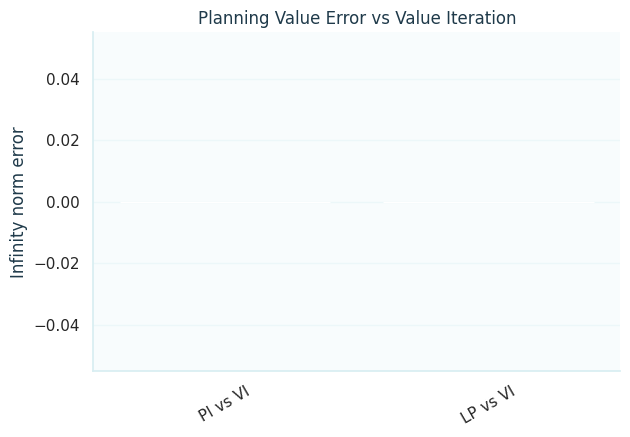

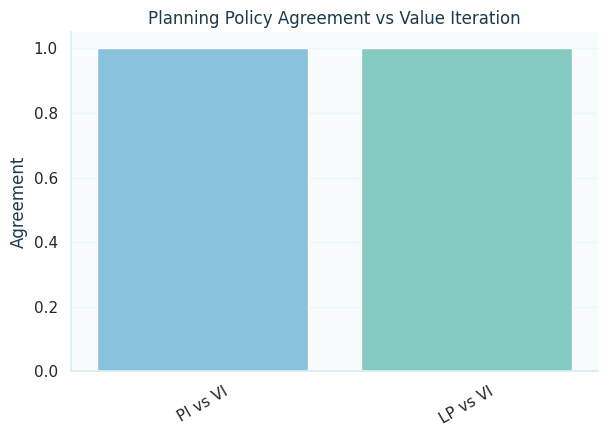

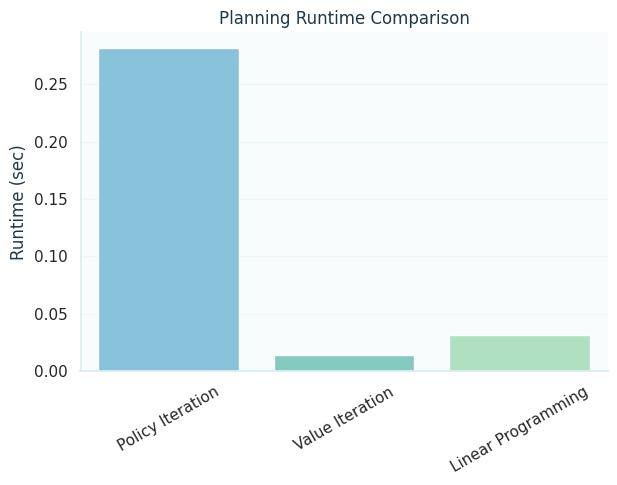

In [21]:
comparison_error_path = NOTEBOOK_FIGURE_DIR / "planning_value_error_comparison.png"
comparison_agreement_path = NOTEBOOK_FIGURE_DIR / "planning_policy_agreement_comparison.png"
comparison_runtime_path = NOTEBOOK_FIGURE_DIR / "planning_runtime_comparison.png"

plot_comparison_bar(
    {
        "PI vs VI": planning_comparison["PI_vs_VI_inf_error"],
        "LP vs VI": planning_comparison["LP_vs_VI_inf_error"],
    },
    "Planning Value Error vs Value Iteration",
    save_path=comparison_error_path,
    ylabel="Infinity norm error",
    show=True,
)

plot_comparison_bar(
    {
        "PI vs VI": planning_comparison["PI_vs_VI_policy_agreement"],
        "LP vs VI": planning_comparison["LP_vs_VI_policy_agreement"],
    },
    "Planning Policy Agreement vs Value Iteration",
    save_path=comparison_agreement_path,
    ylabel="Agreement",
    show=True,
)

plot_comparison_bar(
    {
        "Policy Iteration": planning_comparison["PI_runtime_sec"],
        "Value Iteration": planning_comparison["VI_runtime_sec"],
        "Linear Programming": planning_comparison["LP_runtime_sec"],
    },
    "Planning Runtime Comparison",
    save_path=comparison_runtime_path,
    ylabel="Runtime (sec)",
    show=True,
);


**Nhận xét so sánh Planning Algorithms:**

Kết quả so sánh cho thấy `PolicyIteration` và `LinearProgrammingPlanner` cho nghiệm hoàn toàn nhất quán với `ValueIteration` trên Grid-world hiện tại.

Cụ thể, sai số giữa các value function đều bằng 0.0:

$$
\lVert V_{\mathrm{PI}} - V_{\mathrm{VI}} Vert_{\infty} = 0
$$

$$
\lVert V_{\mathrm{LP}} - V_{\mathrm{VI}} Vert_{\infty} = 0
$$

và:

$$
\mathrm{MSE}(V_{\mathrm{PI}}, V_{\mathrm{VI}}) = 0
$$

$$
\mathrm{MSE}(V_{\mathrm{LP}}, V_{\mathrm{VI}}) = 0
$$

Điều này cho thấy cả ba thuật toán `PolicyIteration`, `ValueIteration` và `LinearProgrammingPlanner` đang tìm được cùng một optimal value function $V^*$.

Biểu đồ **Planning Value Error vs Value Iteration** gần như không hiển thị cột vì sai số bằng 0.0. Đây là kết quả tốt, không phải lỗi biểu đồ. Nó cho thấy nghiệm của Policy Iteration và Linear Programming trùng với nghiệm của Value Iteration theo metric đang xét.

Về policy, cả hai thuật toán cũng đạt policy agreement bằng 1.0 so với Value Iteration:

$$
\mathrm{Agreement}(\pi_{\mathrm{PI}}, \pi_{\mathrm{VI}}) = 1.0
$$

$$
\mathrm{Agreement}(\pi_{\mathrm{LP}}, \pi_{\mathrm{VI}}) = 1.0
$$

Điều này nghĩa là trên toàn bộ non-terminal states, policy từ Policy Iteration và Linear Programming chọn cùng action với policy từ Value Iteration. Nói cách khác, ba thuật toán không chỉ tìm được cùng value function mà còn tìm được cùng policy tối ưu trên môi trường này.

Biểu đồ **Planning Runtime Comparison** cho thấy chi phí chạy của ba thuật toán có sự khác biệt rõ ràng. Trong lần chạy notebook này, `ValueIteration` là thuật toán nhanh nhất, với runtime khoảng 0.041s và 870 Bellman backups. `LinearProgrammingPlanner` có runtime khoảng 0.086s; thuật toán này không dùng Bellman backups lặp mà xây dựng hệ ràng buộc và giải bằng LP solver với 71 solver iterations. `PolicyIteration` chậm hơn rõ rệt, với runtime khoảng 0.225s và 81,490 Bellman backups, vì mỗi vòng policy improvement cần thực hiện policy evaluation bên trong.

Kết quả runtime này không có nghĩa là `PolicyIteration` luôn chậm hơn trong mọi bài toán. Nó chỉ phản ánh cấu hình Grid-world, implementation và tham số hiện tại. Về bản chất, ba thuật toán có cách giải khác nhau:

- `ValueIteration` dùng Bellman optimality backup trực tiếp.
- `PolicyIteration` lặp giữa policy evaluation và policy improvement.
- `LinearProgrammingPlanner` đưa MDP về bài toán tối ưu tuyến tính.

Tóm lại, trên Grid-world 8x8 hiện tại, ba phương pháp Planning đều cho nghiệm tối ưu nhất quán, nhưng chi phí tính toán khác nhau. Phần so sánh này xác nhận rằng các cách tiếp cận khác nhau về mặt thuật toán vẫn có thể hội tụ về cùng nghiệm tối ưu của một MDP hữu hạn.


## Tổng kết Planning

Trong notebook này, ta đã lần lượt xây dựng, chạy và đánh giá bốn thuật toán thuộc nhóm **Planning Algorithms** trên môi trường Grid-world 8x8:

1. **Policy Evaluation**
2. **Policy Iteration**
3. **Value Iteration**
4. **Linear Programming Planner**

Điểm chung của các thuật toán Planning là chúng giả định agent biết đầy đủ model của MDP, tức là biết transition probability $P(s' \mid s,a)$ và reward function $r(s,a,s')$. Nhờ đó, các thuật toán có thể tính toán trực tiếp value function và policy thông qua Bellman equations, thay vì học bằng cách tương tác thử-sai với môi trường.

**Policy Evaluation** được dùng để đánh giá một policy cố định $\pi$. Trong notebook này, policy mặc định là uniform random policy, nên kết quả $V^\pi$ phản ánh chất lượng của một agent hành động ngẫu nhiên. Thuật toán đã hội tụ khi Bellman residual nhỏ hơn ngưỡng $\theta$, cho thấy value function đã gần đạt fixed point:

$$
V^\pi = T^\pi V^\pi
$$

**Policy Iteration** mở rộng ý tưởng của Policy Evaluation bằng cách lặp lại hai bước: đánh giá policy hiện tại và cải thiện policy theo hướng greedy. Thuật toán dừng khi policy trở nên stable, tức là không còn state nào thay đổi action sau bước improvement cuối cùng:

$$
\pi_{k+1}(s) = \pi_k(s), \quad \forall s \in \mathcal{S}
$$

Kết quả cho thấy Policy Iteration tìm được policy ổn định và nhất quán với nghiệm tối ưu của Value Iteration.

**Value Iteration** trực tiếp tìm optimal value function $V^*$ bằng Bellman Optimality Backup:

$$
V_{k+1}(s)
=
\max_a
\sum_{s'} P(s' \mid s,a)
\left[
r(s,a,s') + \gamma V_k(s')
\right]
$$

Thuật toán hội tụ nhanh trên Grid-world hiện tại và trả về optimal policy $\pi^*$ sau khi value function ổn định. Trong project này, Value Iteration đóng vai trò baseline quan trọng để đánh giá các thuật toán optimal planning khác, đồng thời là baseline cho các thuật toán control như SARSA và Q-learning ở notebook Learning.

**Linear Programming Planner** đưa bài toán MDP về một bài toán tối ưu tuyến tính. Thay vì lặp Bellman backup, thuật toán xây dựng hệ ràng buộc Bellman optimality:

$$
V(s)
\ge
\sum_{s'} P(s' \mid s,a)
\left[
r(s,a,s') + \gamma V(s')
\right]
$$

và tối ưu objective:

$$
\min_V \sum_s V(s)
$$

Kết quả cho thấy LP solver tìm được nghiệm optimal, với value function và policy nhất quán với Value Iteration.

Phần so sánh cuối notebook cho thấy Policy Iteration và Linear Programming Planner đều cho kết quả trùng với Value Iteration trên môi trường hiện tại. Cụ thể, sai số value function bằng 0 và policy agreement bằng 1.0:

$$
\lVert V_{\mathrm{PI}} - V_{\mathrm{VI}} \rVert_{\infty} = 0
$$

$$
\lVert V_{\mathrm{LP}} - V_{\mathrm{VI}} \rVert_{\infty} = 0
$$

$$
\mathrm{Agreement}(\pi_{\mathrm{PI}}, \pi_{\mathrm{VI}}) = 1.0
$$

$$
\mathrm{Agreement}(\pi_{\mathrm{LP}}, \pi_{\mathrm{VI}}) = 1.0
$$

Điều này xác nhận rằng các phương pháp Planning khác nhau đều hội tụ về cùng nghiệm tối ưu của MDP hữu hạn này. Tuy nhiên, chi phí tính toán của chúng khác nhau. Value Iteration dùng Bellman optimality backup trực tiếp nên trong thí nghiệm này chạy nhanh và cần ít Bellman backups hơn. Policy Iteration cần nhiều Bellman backups hơn vì phải thực hiện policy evaluation bên trong mỗi vòng policy improvement. Linear Programming không dùng Bellman backups lặp mà giải toàn bộ hệ ràng buộc bằng LP solver.

Tóm lại, notebook Planning cho thấy ba góc nhìn quan trọng trong giải MDP khi biết model:

- **Evaluation view:** Policy Evaluation đánh giá một policy cố định.
- **Dynamic Programming view:** Policy Iteration và Value Iteration giải bài toán tối ưu bằng Bellman equations.
- **Optimization view:** Linear Programming Planner biểu diễn MDP như một bài toán tối ưu tuyến tính.

Các kết quả từ notebook này sẽ được dùng làm nền tảng cho notebook Learning. Cụ thể, Policy Evaluation cung cấp baseline $V^\pi$ cho TD(0) và TD($\lambda$), trong khi Value Iteration cung cấp baseline $V^*$ và $\pi^*$ cho SARSA và Q-learning.
